In [20]:
import json
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial import cKDTree


path = "./dataset/samples"

samples_ae = pd.read_csv(f"{path}/samples_Deter_Deg_CsG_2024_embeddings_alphaearth_pixel.csv")
samples_sentinel = pd.read_csv(f"{path}/samples_Deter_Deg_CsG_2024_sentinel_pixel.csv")

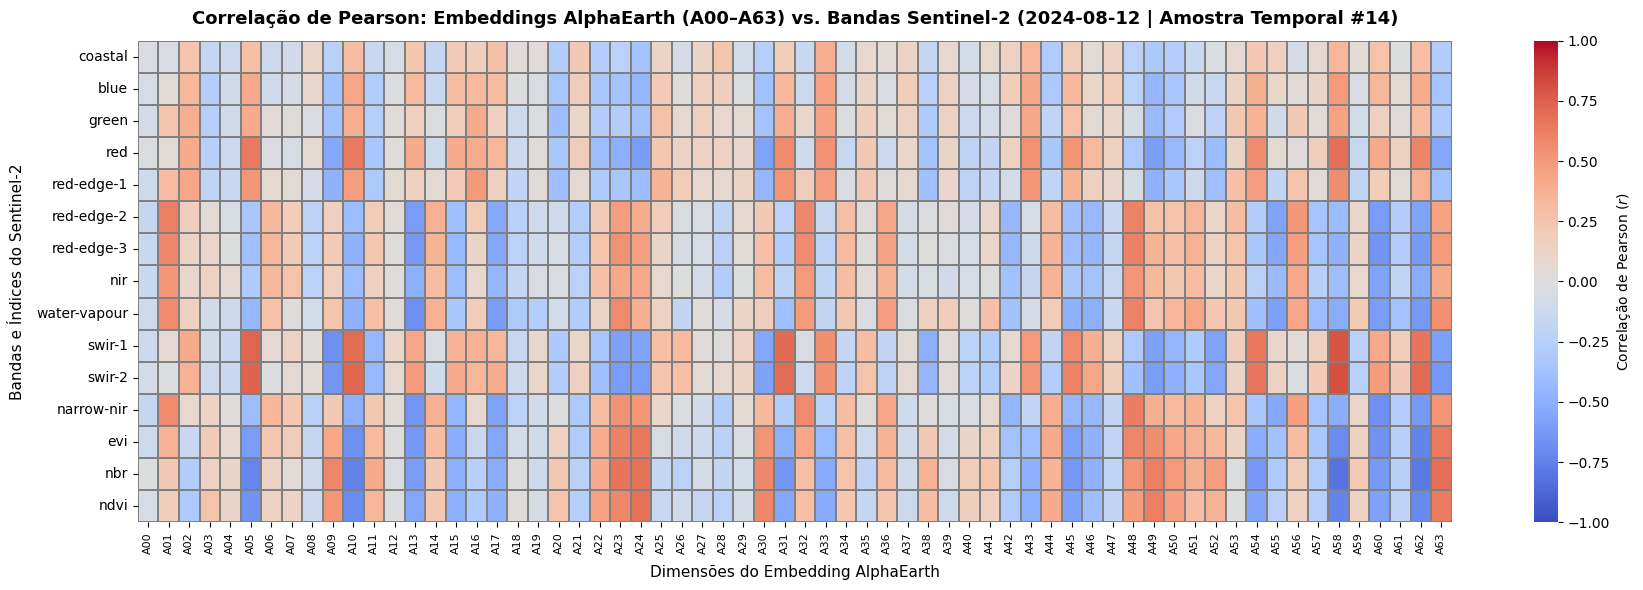

In [18]:
def plot_heatmap(df_ae, df_sentinel, sample_idx=0):
  # Extrair coordenadas (lon, lat) do formato WKT 'POINT (lon lat)'
  def parse_point(geom_str):
    m = re.match(r'POINT \(([^ ]+) ([^ ]+)\)', str(geom_str))
    return (float(m.group(1)), float(m.group(2))) if m else (np.nan, np.nan)

  # Cópia para preservar o DataFrame original
  df_ae_proc = df_ae.copy()
  coords = df_ae_proc['geometry'].apply(parse_point).tolist()
  df_ae_proc[['lon', 'lat']] = pd.DataFrame(coords, index=df_ae_proc.index)

  # Alinhar espacialmente AlphaEarth ao pixel correspondente no Sentinel
  tree = cKDTree(df_sentinel[['longitude', 'latitude']].values)
  _, nearest_indices = tree.query(df_ae_proc[['lon', 'lat']].values)

  # Extrair a série temporal do Sentinel
  matched_ts = [
      json.loads(df_sentinel.loc[idx, 'time_series']) for idx in nearest_indices
  ]
  bands = [k for k in matched_ts[0].keys() if k != 'Index']

  # Obter a data correspondente ao sample_idx escolhido
  num_dates = len(matched_ts[0]['Index'])
  sample_idx = sample_idx % num_dates  # Garante que o índice esteja no intervalo válido (0 a 22)
  selected_date = matched_ts[0]['Index'][sample_idx]

  # Extrair os dados da data selecionada via sample_idx
  df_sentinel_sample = pd.DataFrame({
      band: [ts[band][sample_idx] for ts in matched_ts] for band in bands
  })

  # Selecionar as 64 dimensões dos embeddings AlphaEarth (A00 a A63)
  ae_cols = [f'A{i:02d}' for i in range(64)]
  df_ae_emb = df_ae_proc[ae_cols]

  # Calcular a matriz de correlação de Pearson
  corr_matrix = pd.DataFrame(index=bands, columns=ae_cols, dtype=float)
  for band in bands:
    for col in ae_cols:
      corr_matrix.loc[band, col] = df_ae_emb[col].corr(df_sentinel_sample[band])

  # Gerar e plotar o Heatmap
  plt.figure(figsize=(18, 6))
  sns.heatmap(
      corr_matrix,
      cmap='coolwarm',
      center=0,
      vmin=-1,
      vmax=1,
      cbar_kws={'label': 'Correlação de Pearson ($r$)'},
      linewidths=0.2,
      linecolor='gray',
  )

  plt.title(
      f'Correlação de Pearson: Embeddings AlphaEarth (A00–A63) vs. Bandas'
      f' Sentinel-2 ({selected_date} | Amostra Temporal #{sample_idx})',
      fontsize=13,
      pad=12,
      fontweight='bold',
  )
  plt.xlabel('Dimensões do Embedding AlphaEarth', fontsize=11, labelpad=8)
  plt.ylabel('Bandas e Índices do Sentinel-2', fontsize=11, labelpad=8)
  plt.xticks(rotation=90, fontsize=8)
  plt.yticks(rotation=0, fontsize=10)
  plt.tight_layout()
  plt.show()



sample_n = random.randint(0, len(samples_ae))

# Executar para a amostra aleatória
plot_heatmap(samples_ae, samples_sentinel, sample_n)

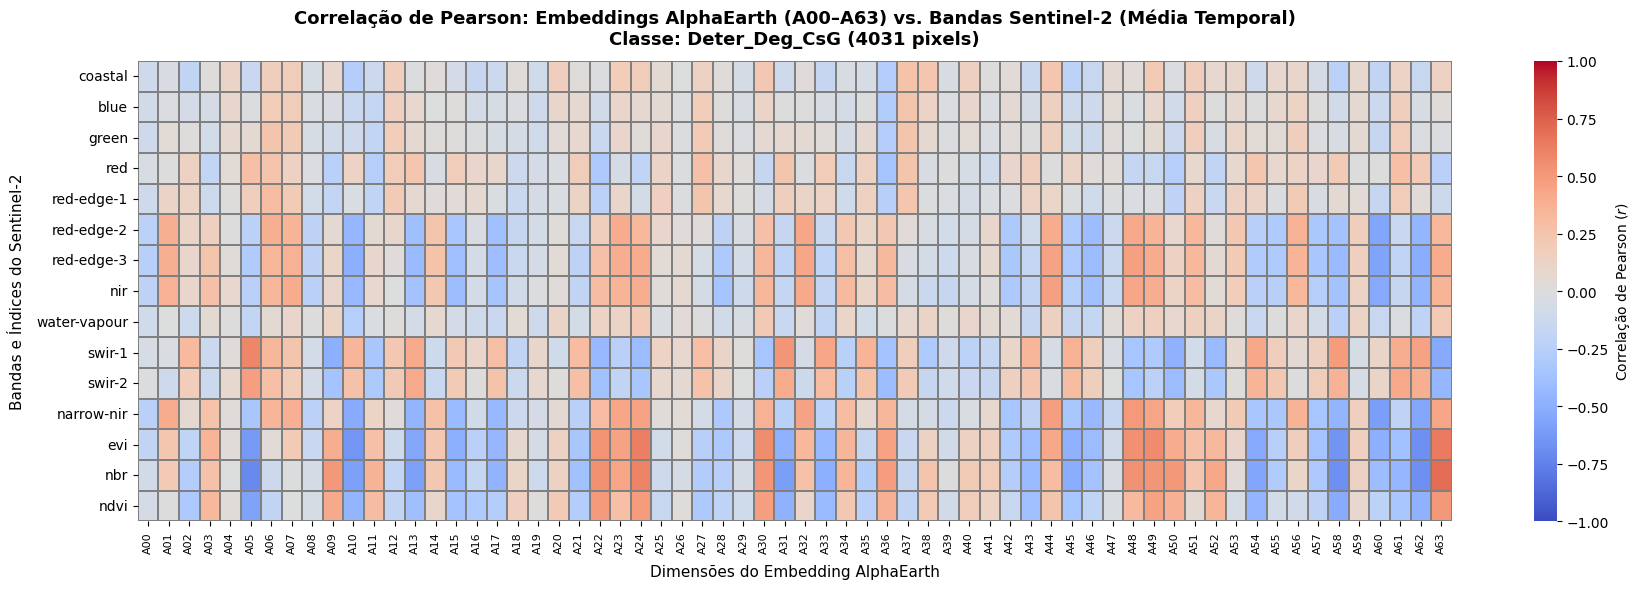

In [19]:
def plot_heatmap(df_ae, df_sentinel, label):
  # 1. Extrair coordenadas (lon, lat) do formato WKT 'POINT (lon lat)'
  def parse_point(geom_str):
    m = re.match(r'POINT \(([^ ]+) ([^ ]+)\)', str(geom_str))
    return (float(m.group(1)), float(m.group(2))) if m else (np.nan, np.nan)

  # 2. Filtrar o dataset AlphaEarth pela classe especificada
  df_ae_filtered = df_ae[df_ae['label'] == label].copy()
  if df_ae_filtered.empty:
    raise ValueError(f"Classe '{label}' não encontrada no DataFrame.")

  coords = df_ae_filtered['geometry'].apply(parse_point).tolist()
  df_ae_filtered[['lon', 'lat']] = pd.DataFrame(
      coords, index=df_ae_filtered.index
  )

  # 3. Alinhar espacialmente os pontos filtrados com o Sentinel
  tree = cKDTree(df_sentinel[['longitude', 'latitude']].values)
  _, nearest_indices = tree.query(df_ae_filtered[['lon', 'lat']].values)

  # 4. Extrair as séries temporais e calcular a MÉDIA temporal por pixel de cada banda
  matched_ts = [
      json.loads(df_sentinel.loc[idx, 'time_series']) for idx in nearest_indices
  ]
  bands = [k for k in matched_ts[0].keys() if k != 'Index']

  df_sentinel_mean = pd.DataFrame({
      band: [np.mean(ts[band]) for ts in matched_ts] for band in bands
  })

  # 5. Selecionar as 64 dimensões dos embeddings AlphaEarth (A00 a A63)
  ae_cols = [f'A{i:02d}' for i in range(64)]
  df_ae_emb = df_ae_filtered[ae_cols].reset_index(drop=True)

  # 6. Calcular a matriz de correlação de Pearson entre os embeddings e as bandas médias
  corr_matrix = pd.DataFrame(index=bands, columns=ae_cols, dtype=float)
  for band in bands:
    for col in ae_cols:
      corr_matrix.loc[band, col] = df_ae_emb[col].corr(df_sentinel_mean[band])

  # 7. Gerar e plotar o Heatmap
  plt.figure(figsize=(18, 6))
  sns.heatmap(
      corr_matrix,
      cmap='coolwarm',
      center=0,
      vmin=-1,
      vmax=1,
      cbar_kws={'label': 'Correlação de Pearson ($r$)'},
      linewidths=0.2,
      linecolor='gray',
  )

  plt.title(
      'Correlação de Pearson: Embeddings AlphaEarth (A00–A63) vs. Bandas'
      ' Sentinel-2 (Média Temporal)\n'
      f'Classe: {label} ({len(df_ae_filtered)} pixels)',
      fontsize=13,
      pad=12,
      fontweight='bold',
  )
  plt.xlabel('Dimensões do Embedding AlphaEarth', fontsize=11, labelpad=8)
  plt.ylabel('Bandas e Índices do Sentinel-2', fontsize=11, labelpad=8)
  plt.xticks(rotation=90, fontsize=8)
  plt.yticks(rotation=0, fontsize=10)
  plt.tight_layout()
  plt.show()


# Executar para a amostra aleatória
plot_heatmap(samples_ae, samples_sentinel, label='Deter_Deg_CsG')